# Start-to-Finish Cartesian Wave Project

## Author: Zach Etienne

To run the whole notebook, click the `>>` toolbar button and choose
**Restart Kernel and Run All Cells...**.

This notebook generates, inspects, builds, runs, and validates a standalone
Cartesian scalar-wave project.

**Notebook Status:** Validated executable project tutorial.

**Validation Notes:** The validation section checks generated diagnostic files
against the trusted exact solution and raises an error unless the sampled
pointwise relative errors pass the stated tolerances. The two-resolution run is
a refinement sanity check, not a measured convergence test.

Navigation: [Index](../index.ipynb) |
Previous: [Wave Equation and C Code Generation](wave_equation_and_c_codegen.ipynb) |
Next: [Reference-Metric Applications][reference-metric-applications]

[reference-metric-applications]: ../4-curvilinear/reference_metric_applications.ipynb

# Table of Contents

1. [Required Reading and Source Code](#Required-Reading-and-Source-Code)
1. [Words for This Notebook](#Words-for-This-Notebook)
1. [Initial-Value Problem](#Initial-Value-Problem)
1. [Workspace and Generated Files](#Workspace-and-Generated-Files)
1. [Step 1: Import Project Execution Helpers](#Step-1:-Import-Project-Execution-Helpers)
1. [Step 2: Set the Project Workspace](#Step-2:-Set-the-Project-Workspace)
1. [Step 3: Generate the Cartesian Wave Project](#Step-3:-Generate-the-Cartesian-Wave-Project)
1. [Step 4: Inspect Generated Files](#Step-4:-Inspect-Generated-Files)
1. [Step 5: Inspect Runtime and Source Artifacts](#Step-5:-Inspect-Runtime-and-Source-Artifacts)
1. [Step 6: Build and Run](#Step-6:-Build-and-Run)
1. [Validation Check](#Validation-Check)
1. [Step 7: Plot Diagnostic Error Histories](#Step-7:-Plot-Diagnostic-Error-Histories)
1. [What next?](#What-next?)

# Required Reading and Source Code
### [Back to [top](#Table-of-Contents)]

Required reading:

- [Wave Equation and C Code Generation](wave_equation_and_c_codegen.ipynb)
- [Finite-Difference Playground](../2-numerical_methods/finite_difference_playground.ipynb)
- [Method of Lines and RK](../2-numerical_methods/method_of_lines_and_rk.ipynb)

Installed NRPy modules used here:

- `nrpy.examples.wave_equation_cartesian`
  (`examples/wave_equation_cartesian.py`): generates the project inspected
  below.
- `nrpy.infrastructures.BHaH.wave_equation.rhs_eval`
  (`infrastructures/BHaH/wave_equation/rhs_eval.py`): registers the generated
  wave right-hand-side C function.
- `nrpy.infrastructures.BHaH.wave_equation.initial_data_exact_soln`
  (`infrastructures/BHaH/wave_equation/initial_data_exact_soln.py`):
  registers initial-data and exact-solution routines.
- `nrpy.infrastructures.BHaH.Makefile_helpers`
  (`infrastructures/BHaH/Makefile_helpers.py`): supports generated build
  files.
- `nrpy.infrastructures.BHaH.MoLtimestepping.register_all`
  (`infrastructures/BHaH/MoLtimestepping/register_all.py`): generates
  Method-of-Lines time stepping.

These are package-relative paths inside the pip-installed `nrpy`; no cloned
source checkout is required.

# Words for This Notebook
### [Back to [top](#Table-of-Contents)]

- **`u`:** the scalar wave amplitude.
- **`v`:** the auxiliary time derivative `v = partial_t u`.
- **Wave speed:** the parameter `wavespeed`, here normalized to `1`.
- **Gridfunction:** an array-valued field stored on the numerical grid.
- **BHaH:** NRPy's standalone generated-code infrastructure.
- **CodeParameter:** a runtime or compile-time setting written into generated
  code or a parameter file.
- **Generated project:** a directory containing generated source, build files,
  runtime parameters, an executable, and diagnostics.
- **Parameter file:** a text file of runtime settings read by the executable.
- **Makefile:** the build recipe used by `make`.
- **Executable:** the compiled program that advances the wave system.
- **Right-hand-side source:** the generated C file that computes time
  derivatives for `u` and `v`.
- **Finite-difference stencil:** neighboring grid-point values used to
  approximate derivatives.
- **Ghost zone:** grid points outside the physical interior used by stencils
  and boundary conditions.
- **Method of Lines:** the time-stepping approach that turns spatially
  discretized PDEs into ODEs in time.
- **Diagnostic file:** runtime output used to judge numerical behavior.

# Initial-Value Problem
### [Back to [top](#Table-of-Contents)]

The generated project solves the Cartesian scalar wave equation

$$
\partial_t^2 u = c^2
\left(\partial_x^2 u + \partial_y^2 u + \partial_z^2 u\right),
\qquad c = 1.
$$

The evolved variables are `u` and `v = partial_t u`. The project initializes
them from a trusted analytic plane-wave solution, advances them with RK4 Method
of Lines time stepping, fills Cartesian ghost zones through generated boundary
code, and writes sampled diagnostics at the grid center. Each diagnostic row
stores time, relative `u` error, relative `v` error, numerical `u`, and exact
`u`. The expected behavior is that sampled relative errors remain below the
regression tolerances and that the refined run is more accurate at the sampled
point than the default run.

# Workspace and Generated Files
### [Back to [top](#Table-of-Contents)]

This notebook owns `project/wave_equation_cartesian` relative to the
`3-wave_equation` notebook directory. Each run regenerates that directory only
if it contains the ownership marker `.nrpy_tutorial_owned`; otherwise the
notebook stops to avoid deleting user files.

| Artifact | Role | Where used |
| --- | --- | --- |
| `.nrpy_tutorial_owned` | ownership marker | regeneration guard |
| `wave_equation_cartesian.par` | runtime settings | build/run and validation |
| `Makefile` | build rules | build step |
| `BHaH_function_prototypes.h` | declarations | source inspection |
| `rhs_eval.c` | wave update formula | source inspection and executable |
| `MoL/` files | RK time stepping | executable |
| `apply_bcs.c` | Cartesian boundary fill | executable |
| `diagnostics.c` | sampled error writer | validation |
| `out0d-conv_factor*.txt` | diagnostics | validation and plot |

Inspect the marker slug/generator, parameter values, compiler settings,
callable prototypes, RHS grid loop and stencil reads, Method-of-Lines stages,
boundary entry point, diagnostic columns, and sampled relative errors.

# Step 1: Import Project Execution Helpers
### [Back to [top](#Table-of-Contents)]

These setup cells import standard-library tools and define command helpers. On
a first pass, skim the helper definitions; they manage the generated project,
run terminal commands, and make failures loud.

In [1]:
from pathlib import Path
import math
import re
import shutil
import subprocess
import sys


PROJECT_ROOT = Path.cwd()
NOTEBOOK_NAME = "start_to_finish_wave_cartesian.ipynb"
GENERATOR_MODULE = "nrpy.examples.wave_equation_cartesian"
WARNING_RE = re.compile(r"(^|: )warning:", re.IGNORECASE)

In [2]:
def display_path(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT.resolve())


def clean_command_output(text):
    return (text or "").replace(str(PROJECT_ROOT), "<notebook-dir>")


def command_has_warning(text):
    for line in (text or "").splitlines():
        stripped = line.strip()
        if stripped.startswith("WARNING:") or WARNING_RE.search(stripped):
            return True
    return False


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=False,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    output = clean_command_output(result.stdout)
    if result.returncode != 0:
        print(output)
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}")
    if command_has_warning(output):
        print(output)
        raise RuntimeError(f"Command emitted warning output: {args}")
    return output

In [3]:
def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError("This notebook requires make.")
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError("This notebook requires a C compiler.")


def replace_once(text, old, new, label):
    count = text.count(old)
    if count != 1:
        raise RuntimeError(f"Expected one {label} setting; found {count}.")
    print("updated runtime setting:", label)
    return text.replace(old, new, 1)


def print_markdown_table(headers, rows):
    print("| " + " | ".join(headers) + " |")
    print("| " + " | ".join("---" for _ in headers) + " |")
    for row in rows:
        print("| " + " | ".join(str(value) for value in row) + " |")

In [4]:
def prepare_owned_project(project_dir, marker_text):
    marker = project_dir / ".nrpy_tutorial_owned"
    existed = project_dir.exists()
    print("project path:", display_path(project_dir))
    print("directory existed before generation:", existed)
    print("cleanup policy: guarded delete and regenerate")
    if existed and not marker.is_file():
        raise RuntimeError(
            f"{display_path(project_dir)} exists without .nrpy_tutorial_owned."
        )
    if existed:
        shutil.rmtree(project_dir)
    project_dir.parent.mkdir(parents=True, exist_ok=True)
    return marker_text


def write_ownership_marker(project_dir, marker_text):
    marker = project_dir / ".nrpy_tutorial_owned"
    marker.write_text(marker_text, encoding="utf-8")
    print("ownership marker:", marker.relative_to(project_dir))

# Step 2: Set the Project Workspace
### [Back to [top](#Table-of-Contents)]

The project path is stable and notebook-local. The next cell prints the path
and the cleanup policy before any generated files are written.

In [5]:
PROJECT_NAME = "wave_equation_cartesian"
PROJECT_DIR = PROJECT_ROOT / "project" / PROJECT_NAME
MARKER_TEXT = (
    f"owned_by = {NOTEBOOK_NAME}\n"
    f"generator = python -m {GENERATOR_MODULE}\n"
    "policy = this tutorial may delete and regenerate this directory\n"
)
prepare_owned_project(PROJECT_DIR, MARKER_TEXT)

project path: project/wave_equation_cartesian
directory existed before generation: True
cleanup policy: guarded delete and regenerate


'owned_by = start_to_finish_wave_cartesian.ipynb\ngenerator = python -m nrpy.examples.wave_equation_cartesian\npolicy = this tutorial may delete and regenerate this directory\n'

# Step 3: Generate the Cartesian Wave Project
### [Back to [top](#Table-of-Contents)]

This cell invokes the same generator a learner can run from a terminal. It then
shortens runtime-only settings so the notebook executes quickly.

In [6]:
command = [sys.executable, "-m", GENERATOR_MODULE]
print("generator command:", "python -m", GENERATOR_MODULE)
generator_output = run_command(command, PROJECT_ROOT, timeout=300)
print(generator_output.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)
write_ownership_marker(PROJECT_DIR, MARKER_TEXT)

generator command: python -m nrpy.examples.wave_equation_cartesian


Finished! Now go into project/wave_equation_cartesian and type `make` to build, then ./wave_equation_cartesian to run.
    Parameter file can be found in wave_equation_cartesian.par
ownership marker: .nrpy_tutorial_owned


In [7]:
parfile = PROJECT_DIR / "wave_equation_cartesian.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = replace_once(par_text, "t_final = 8.0", "t_final = 0.2", "final time")
par_text = replace_once(
    par_text,
    "diagnostics_output_every = 0.2",
    "diagnostics_output_every = 0.1",
    "diagnostic output interval",
)
par_text = replace_once(
    par_text,
    "output_progress_every = 1",
    "output_progress_every = 1000000",
    "progress output interval",
)
parfile.write_text(par_text, encoding="utf-8")

updated runtime setting: final time
updated runtime setting: diagnostic output interval
updated runtime setting: progress output interval


852

# Step 4: Inspect Generated Files
### [Back to [top](#Table-of-Contents)]

The inventory below is the complete pre-build file list. It is printed before
`make`, so object files and the executable are not mixed into the generated
source inventory.

In [8]:
prebuild_files = sorted(
    path.relative_to(PROJECT_DIR)
    for path in PROJECT_DIR.rglob("*")
    if path.is_file()
)
print("complete pre-build generated-file inventory:")
for relative_path in prebuild_files:
    print(relative_path)
print("pre-build file count:", len(prebuild_files))

complete pre-build generated-file inventory:
.nrpy_tutorial_owned
BHaH_defines.h
BHaH_function_prototypes.h
Makefile
MoL/MoL_free_intermediate_stage_gfs.c
MoL/MoL_malloc_intermediate_stage_gfs.c
MoL/MoL_step_forward_in_time.c
apply_bcs.c
cmdline_input_and_parfile_parser.c
commondata_struct_set_to_default.c
diagnostics.c
exact_solution_single_Cartesian_point.c
griddata_free.c
initial_data.c
intrinsics/simd_intrinsics.h
main.c
numerical_grids_and_timestep.c
params_struct_set_to_default.c
progress_indicator.c
rhs_eval.c
set_CodeParameters-nopointer.h
set_CodeParameters-simd.h
set_CodeParameters.h
wave_equation_cartesian.par
pre-build file count: 24


# Step 5: Inspect Runtime and Source Artifacts
### [Back to [top](#Table-of-Contents)]

The next cells print complete bounded artifacts from the catalog. Inspect the
parameter values, complete build rules, function declarations, and the RHS grid
loop with finite-difference reads and RHS writes.

In [9]:
print("--- wave_equation_cartesian.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))

--- wave_equation_cartesian.par ---
#### wave_equation_cartesian BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: __main__
convergence_factor = 1.0        # (REAL)
diagnostics_output_every = 0.1  # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.diagnostics.progress_indicator
output_progress_every = 1000000       # (int)



In [10]:
print("--- Makefile ---")
print((PROJECT_DIR / "Makefile").read_text(encoding="utf-8", errors="replace"))

--- Makefile ---
CC ?= gcc  # assigns the value CC to gcc only if environment variable CC is not already set

CFLAGS = -std=gnu99 -O2 -march=native -g -Wall -I.
CXXFLAGS = -I. -O2 -g -Wall -Wno-unknown-pragmas -march=native
VALGRIND_CFLAGS = -I. -std=gnu99 -O2 -g -Wall -Wno-unknown-pragmas
INCLUDEDIRS =
LDFLAGS = -lm
# Check for OpenMP support
OPENMP_FLAG = -fopenmp
COMPILER_SUPPORTS_OPENMP := $(shell echo | $(CC) $(OPENMP_FLAG) -E - >/dev/null 2>&1 && echo YES || echo NO)

ifeq ($(COMPILER_SUPPORTS_OPENMP), YES)
    CFLAGS += $(OPENMP_FLAG)
    LDFLAGS += $(OPENMP_FLAG)
endif

OBJ_FILES = apply_bcs.o cmdline_input_and_parfile_parser.o commondata_struct_set_to_default.o diagnostics.o exact_solution_single_Cartesian_point.o griddata_free.o initial_data.o main.o MoL/MoL_free_intermediate_stage_gfs.o MoL/MoL_malloc_intermediate_stage_gfs.o MoL/MoL_step_forward_in_time.o numerical_grids_and_timestep.o params_struct_set_to_default.o progress_indicator.o rhs_eval.o

all: wave_equation_cartes

In [11]:
print("--- BHaH_function_prototypes.h ---")
print(
    (PROJECT_DIR / "BHaH_function_prototypes.h").read_text(
        encoding="utf-8", errors="replace"
    )
)

--- BHaH_function_prototypes.h ---
void apply_bcs(const commondata_struct *restrict commondata, const params_struct *restrict params, REAL *restrict gfs);
void cmdline_input_and_parfile_parser(commondata_struct *restrict commondata, int argc, const char *argv[]);
void commondata_struct_set_to_default(commondata_struct *restrict commondata);
void diagnostics(commondata_struct *restrict commondata, griddata_struct *restrict griddata);
void exact_solution_single_Cartesian_point(const commondata_struct *restrict commondata, const params_struct *restrict params, const REAL xCart0,
                                           const REAL xCart1, const REAL xCart2, REAL *restrict exact_soln_UUGF, REAL *restrict exact_soln_VVGF);
void griddata_free(commondata_struct *restrict commondata, griddata_struct *restrict griddata,
                   const bool free_non_y_n_gfs_and_core_griddata_pointers);
void initial_data(const commondata_struct *restrict commondata, griddata_struct *restrict griddata);

In [12]:
print("--- rhs_eval.c ---")
print((PROJECT_DIR / "rhs_eval.c").read_text(encoding="utf-8", errors="replace"))

--- rhs_eval.c ---
#include "BHaH_defines.h"
#include "intrinsics/simd_intrinsics.h"

/**
 * Set RHSs for wave equation.
 */
void rhs_eval(const commondata_struct *restrict commondata, const params_struct *restrict params, const REAL *restrict in_gfs,
              REAL *restrict rhs_gfs) {
#include "set_CodeParameters-simd.h"
#pragma omp parallel for
  for (int i2 = NGHOSTS; i2 < Nxx_plus_2NGHOSTS2 - NGHOSTS; i2++) {
    for (int i1 = NGHOSTS; i1 < Nxx_plus_2NGHOSTS1 - NGHOSTS; i1++) {
      for (int i0 = NGHOSTS; i0 < Nxx_plus_2NGHOSTS0 - NGHOSTS; i0 += SIMD_WIDTH) {

        /*
         * NRPy-Generated GF Access/FD Code, Step 1 of 2:
         * Read gridfunction(s) from main memory and compute FD stencils as needed.
         */
        const REAL_SIMD_ARRAY uu_i2m2 = ReadSIMD(&in_gfs[IDX4(UUGF, i0, i1, i2 - 2)]);
        const REAL_SIMD_ARRAY uu_i2m1 = ReadSIMD(&in_gfs[IDX4(UUGF, i0, i1, i2 - 1)]);
        const REAL_SIMD_ARRAY uu_i1m2 = ReadSIMD(&in_gfs[IDX4(UUGF, i0, i1 - 2, i2)]

# Step 6: Build and Run
### [Back to [top](#Table-of-Contents)]

The build result table is the evidence for successful compilation. Raw compiler
progress is not required evidence here; if the compiler emits a warning or
fails, the helper prints the complete captured log and raises an error.

In [13]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
executable = PROJECT_DIR / PROJECT_NAME
if not executable.is_file():
    raise FileNotFoundError(executable)
c_source_count = len(list(PROJECT_DIR.rglob("*.c")))
object_count = len(list(PROJECT_DIR.rglob("*.o")))
build_line_count = len([line for line in build_output.splitlines() if line.strip()])
print_markdown_table(
    ["field", "value"],
    [
        ["command", "make -j2"],
        ["project", display_path(PROJECT_DIR)],
        ["return status", 0],
        ["executable", executable.relative_to(PROJECT_DIR)],
        ["C source count", c_source_count],
        ["object file count", object_count],
        ["build output line count", build_line_count],
    ],
)

| field | value |
| --- | --- |
| command | make -j2 |
| project | project/wave_equation_cartesian |
| return status | 0 |
| executable | wave_equation_cartesian |
| C source count | 15 |
| object file count | 15 |
| build output line count | 16 |


The default run uses the parameter file as displayed above. The refined run
repeats the same executable with convergence factor `2.0`, which increases the
resolution used by the generated code.

In [14]:
default_output = run_command([f"./{PROJECT_NAME}"], PROJECT_DIR, timeout=90)
print("complete run output (default resolution):")
print(default_output.rstrip() or "<no output>")

complete run output (default resolution):
It: 0 t=0.000 / 0.2 = 0.00% dt=1/6.4 | t/h=0.00 ETA 0h00m00s


In [15]:
refined_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=90)
print("complete run output (convergence factor 2.0):")
print(refined_output.rstrip() or "<no output>")

complete run output (convergence factor 2.0):
It: 0 t=0.000 / 0.2 = 0.00% dt=1/12.8 | t/h=0.00 ETA 0h00m00s


# Validation Check
### [Back to [top](#Table-of-Contents)]

The trusted result is the exact plane-wave solution used by the generated
diagnostic writer. The newly computed result is the sampled numerical value in
each diagnostic file. The error metric is pointwise absolute relative error:
`abs(column 1)` for `u` and `abs(column 2)` for `v`.

The tolerances below are regression tolerances. They are loose enough not to
require roundoff-level agreement, but tight enough to catch broken generated
code. With only two resolutions this is a refinement sanity check, not a
measured convergence test.

In [16]:
EXPECTED_DIAGNOSTIC_COLUMNS = 5
MAX_ABS_UU_RELERROR = 1.0e-5
MAX_ABS_VV_RELERROR = 1.0e-3
diagnostic_rows = {}
for diagnostic in sorted(PROJECT_DIR.glob("out0d-conv_factor*.txt")):
    rows = [
        [float(value) for value in line.split()]
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip()
    ]
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two rows in {diagnostic.name}.")
    for row in rows:
        if len(row) != EXPECTED_DIAGNOSTIC_COLUMNS:
            raise RuntimeError(f"Expected five columns in {diagnostic.name}.")
    diagnostic_rows[diagnostic.name] = rows

In [17]:
expected_diagnostics = {"out0d-conv_factor1.00.txt", "out0d-conv_factor2.00.txt"}
missing_diagnostics = expected_diagnostics.difference(diagnostic_rows)
if missing_diagnostics:
    raise FileNotFoundError(f"Missing diagnostics: {sorted(missing_diagnostics)}")
validation_rows = []
for diagnostic_name, rows in sorted(diagnostic_rows.items()):
    factor = diagnostic_name.removeprefix("out0d-conv_factor").removesuffix(".txt")
    final_row = rows[-1]
    abs_u_error = abs(final_row[1])
    abs_v_error = abs(final_row[2])
    if not math.isfinite(abs_u_error) or not math.isfinite(abs_v_error):
        raise RuntimeError(f"Expected finite errors in {diagnostic_name}.")
    passed = abs_u_error <= MAX_ABS_UU_RELERROR and abs_v_error <= MAX_ABS_VV_RELERROR
    validation_rows.append(
        [
            diagnostic_name,
            factor,
            final_row[0],
            f"{abs_u_error:.6e}",
            f"{abs_v_error:.6e}",
            MAX_ABS_UU_RELERROR,
            MAX_ABS_VV_RELERROR,
            "PASS" if passed else "FAIL",
        ]
    )
    if not passed:
        raise RuntimeError(f"Diagnostic tolerance failed for {diagnostic_name}.")

In [18]:
coarse_final = diagnostic_rows["out0d-conv_factor1.00.txt"][-1]
refined_final = diagnostic_rows["out0d-conv_factor2.00.txt"][-1]
if abs(refined_final[1]) >= abs(coarse_final[1]):
    raise RuntimeError("Expected refined u error below the default run.")
if abs(refined_final[2]) >= abs(coarse_final[2]):
    raise RuntimeError("Expected refined v error below the default run.")
print_markdown_table(
    [
        "diagnostic",
        "resolution multiplier",
        "final sampled time",
        "abs relative u error",
        "abs relative v error",
        "u tolerance",
        "v tolerance",
        "status",
    ],
    validation_rows,
)
print("PASS: Cartesian sampled diagnostics pass the refinement sanity check.")

| diagnostic | resolution multiplier | final sampled time | abs relative u error | abs relative v error | u tolerance | v tolerance | status |
| --- | --- | --- | --- | --- | --- | --- | --- |
| out0d-conv_factor1.00.txt | 1.00 | 0.15625 | 4.061498e-08 | 2.140944e-05 | 1e-05 | 0.001 | PASS |
| out0d-conv_factor2.00.txt | 2.00 | 0.078125 | 6.435354e-10 | 1.354916e-06 | 1e-05 | 0.001 | PASS |
PASS: Cartesian sampled diagnostics pass the refinement sanity check.


# Step 7: Plot Diagnostic Error Histories
### [Back to [top](#Table-of-Contents)]

The plot shows the sampled absolute relative `u` error over time for both
resolution multipliers. The refined curve should remain below the default run
at the sampled times available in the shortened notebook run.

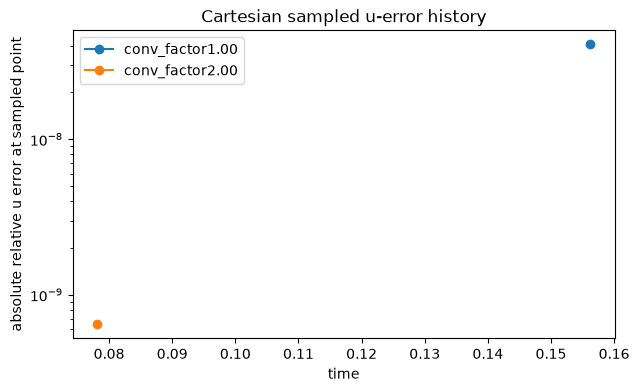

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for name, rows in sorted(diagnostic_rows.items()):
    positive_rows = [row for row in rows if abs(row[1]) > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [abs(row[1]) for row in positive_rows]
    label = name.replace("out0d-", "").replace(".txt", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("absolute relative u error at sampled point")
plt.title("Cartesian sampled u-error history")
plt.legend()
plt.show()

The generated project directory, source files, executable, diagnostic files,
validation table, and plot together show a complete Cartesian wave workflow
from generation through runtime checking.

# What next?
### [Back to [top](#Table-of-Contents)]

- [Curvilinear Wave Equation](wave_equation_curvilinear.ipynb)
- [Reference-Metric Applications](../4-curvilinear/reference_metric_applications.ipynb)
- [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)